In [1]:
import matplotlib.pyplot as plt
import os
import re

os.makedirs('../reports/charts', exist_ok=True)
if not hasattr(plt, '_original_show'):
    plt._original_show = plt.show
    plt._plot_counter = 1

    def _custom_show(*args, **kwargs):
        title = plt.gca().get_title()
        if title:
            clean_title = re.sub(r'[^\w\-_\. ]', '_', title).strip().replace(' ', '_')
            filename = f'../reports/charts/{clean_title}_{plt._plot_counter}.png'
        else:
            filename = f'../reports/charts/03_feature_engineering_figure_{plt._plot_counter}.png'
            
        try:
            plt.savefig(filename, bbox_inches='tight')
            print(f"Saved chart to {filename}")
        except Exception as e:
            print(f"Warning: Could not save figure {filename}: {e}")
            
        plt._plot_counter += 1
        plt._original_show(*args, **kwargs)

    plt.show = _custom_show


---

# 4.3 Feature Engineering

This notebook builds all derived features on top of the cleaned datasets produced in `02_data_cleanup_and_filteration.ipynb`.

**Reference files used:**
- `../data/raw/state_crosswalk.csv` — canonical state codes, valid-from/to years, bifurcation history  
- `../data/raw/state_name_audit.csv` — raw state names identified during the audit pass  
- `../data/raw/state_name_variants.csv` — variant → canonical name lookup (also used in cleanup notebook)

**Filtered inputs expected:**
```
../data/interim/clean_election_results_1951_2019.csv
../data/interim/clean_loksabha_1962_2019.csv
../data/interim/clean_election_results_2024.csv
../data/interim/clean_ref_party_master.csv
```

---
## Imports & Data Loading

In [2]:
import os
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [3]:
# ─── Reference files ────────────────────────────────────────────────────────
state_crosswalk     = pd.read_csv('../data/raw/state_crosswalk.csv')
state_name_audit    = pd.read_csv('../data/raw/state_name_audit.csv')
state_name_variants = pd.read_csv('../data/raw/state_name_variants.csv')

# ─── Cleaned election datasets (output of cleanup notebook) ─────────────────
df_1951_2019 = pd.read_csv('../data/interim/clean_election_results_1951_2019.csv')
df_loksabha  = pd.read_csv('../data/interim/clean_loksabha_1962_2019.csv')
df_2024      = pd.read_csv('../data/interim/clean_election_results_2024.csv')
df_party     = pd.read_csv('../data/interim/clean_ref_party_master.csv')

print('Loaded datasets:')
print(f'  clean_election_results_1951_2019 : {df_1951_2019.shape}')
print(f'  clean_loksabha_1962_2019         : {df_loksabha.shape}')
print(f'  clean_election_results_2024      : {df_2024.shape}')
print(f'  clean_ref_party_master           : {df_party.shape}')

Loaded datasets:
  clean_election_results_1951_2019 : (89840, 19)
  clean_loksabha_1962_2019         : (8047, 15)
  clean_election_results_2024      : (8902, 16)
  clean_ref_party_master           : (10153, 27)


### 4.3.1 Vote swing (current vs. previous election)

The absolute change in the percentage of votes received by a specific party in a specific constituency from the immediately preceding election to the current one.

Formula:$$\Delta V_{i,t} = V_{i,t} - V_{i,t-1}$$

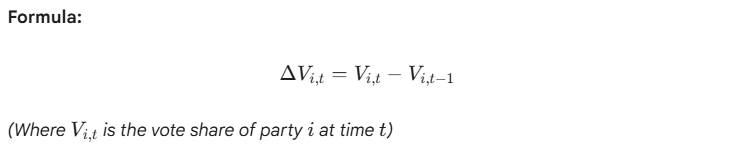

In [4]:
# Sort data chronologically within each state and constituency for each party
df_features = df_1951_2019.sort_values(by=['state_canonical', 'constitution', 'party', 'election_year_clean'])

# Shift by 1 to get the previous election's vote share
df_features['vote_share_lag1'] = df_features.groupby(['state_canonical', 'constitution', 'party'])['vote_share_pct'].shift(1)

# Calculate the swing
df_features['vote_swing'] = df_features['vote_share_pct'] - df_features['vote_share_lag1']

df_features.head()

,id,state,constitution,election_year,candidate,gender,party,age,category,votes_received,...,num_seats,state_pc_year,rank,result,election_year_clean,vote_share_pct,state_raw,state_canonical,vote_share_lag1,vote_swing
29287,8256.0,ANDAMAN AND NICOBAR ISLANDS,ANDAMAN & NICOBAR ISLANDS,1991 (10th LOK SABHA),BISHNU PADA RAY,M,BJP,NaN,NaN,5208.0,...,1,ANDAMAN AND NICOBAR ISLANDS-ANDAMAN & NICOBAR ...,3,2nd runner up,1991,4.85,ANDAMAN AND NICOBAR ISLANDS,ANDAMAN AND NICOBAR ISLANDS,NaN,NaN
37917,12395.0,ANDAMAN AND NICOBAR ISLANDS,ANDAMAN & NICOBAR ISLANDS,1996 (11th LOK SABHA),BISHNU PADA RAY,M,BJP,NaN,NaN,31097.0,...,1,ANDAMAN AND NICOBAR ISLANDS-ANDAMAN & NICOBAR ...,2,1st runner up,1996,24.25,ANDAMAN AND NICOBAR ISLANDS,ANDAMAN AND NICOBAR ISLANDS,4.85,19.40
50156,4665.0,ANDAMAN AND NICOBAR ISLANDS,ANDAMAN & NICOBAR ISLANDS,1998 (12th LOK SABHA),BISHNU PADA RAY,M,BJP,NaN,NaN,51821.0,...,1,ANDAMAN AND NICOBAR ISLANDS-ANDAMAN & NICOBAR ...,2,1st runner up,1998,35.53,ANDAMAN AND NICOBAR ISLANDS,ANDAMAN AND NICOBAR ISLANDS,24.25,11.28
54903,4594.0,ANDAMAN AND NICOBAR ISLANDS,ANDAMAN & NICOBAR ISLANDS,1999 (13th LOK SABHA),BISHNU PADA RAY,M,BJP,NaN,NaN,76891.0,...,1,ANDAMAN AND NICOBAR ISLANDS-ANDAMAN & NICOBAR ...,1,winner,1999,52.74,ANDAMAN AND NICOBAR ISLANDS,ANDAMAN AND NICOBAR ISLANDS,35.53,17.21
59566,5307.0,ANDAMAN AND NICOBAR ISLANDS,ANDAMAN & NICOBAR ISLANDS,2004 (14th LOK SABHA),BISHNU PADA RAY,M,BJP,54.0,NaN,55294.0,...,1,ANDAMAN AND NICOBAR ISLANDS-ANDAMAN & NICOBAR ...,2,1st runner up,2004,35.95,ANDAMAN AND NICOBAR ISLANDS,ANDAMAN AND NICOBAR ISLANDS,52.74,-16.79


### 4.3.2 Lagged vote share (t‑1, t‑2)

The percentage of votes a party secured in the immediate past election ($t-1$) and the election prior to that ($t-2$) within the exact same constituency.

Formula:$$L_{1} = V_{i,t-1}, \quad L_{2} = V_{i,t-2}$$

In [5]:
# Utilizing the sorted dataframe from above
df_features['vote_share_lag2'] = df_features.groupby(['state_canonical', 'constitution', 'party'])['vote_share_pct'].shift(2)
df_features.head()

,id,state,constitution,election_year,candidate,gender,party,age,category,votes_received,...,state_pc_year,rank,result,election_year_clean,vote_share_pct,state_raw,state_canonical,vote_share_lag1,vote_swing,vote_share_lag2
29287,8256.0,ANDAMAN AND NICOBAR ISLANDS,ANDAMAN & NICOBAR ISLANDS,1991 (10th LOK SABHA),BISHNU PADA RAY,M,BJP,NaN,NaN,5208.0,...,ANDAMAN AND NICOBAR ISLANDS-ANDAMAN & NICOBAR ...,3,2nd runner up,1991,4.85,ANDAMAN AND NICOBAR ISLANDS,ANDAMAN AND NICOBAR ISLANDS,NaN,NaN,NaN
37917,12395.0,ANDAMAN AND NICOBAR ISLANDS,ANDAMAN & NICOBAR ISLANDS,1996 (11th LOK SABHA),BISHNU PADA RAY,M,BJP,NaN,NaN,31097.0,...,ANDAMAN AND NICOBAR ISLANDS-ANDAMAN & NICOBAR ...,2,1st runner up,1996,24.25,ANDAMAN AND NICOBAR ISLANDS,ANDAMAN AND NICOBAR ISLANDS,4.85,19.40,NaN
50156,4665.0,ANDAMAN AND NICOBAR ISLANDS,ANDAMAN & NICOBAR ISLANDS,1998 (12th LOK SABHA),BISHNU PADA RAY,M,BJP,NaN,NaN,51821.0,...,ANDAMAN AND NICOBAR ISLANDS-ANDAMAN & NICOBAR ...,2,1st runner up,1998,35.53,ANDAMAN AND NICOBAR ISLANDS,ANDAMAN AND NICOBAR ISLANDS,24.25,11.28,4.85
54903,4594.0,ANDAMAN AND NICOBAR ISLANDS,ANDAMAN & NICOBAR ISLANDS,1999 (13th LOK SABHA),BISHNU PADA RAY,M,BJP,NaN,NaN,76891.0,...,ANDAMAN AND NICOBAR ISLANDS-ANDAMAN & NICOBAR ...,1,winner,1999,52.74,ANDAMAN AND NICOBAR ISLANDS,ANDAMAN AND NICOBAR ISLANDS,35.53,17.21,24.25
59566,5307.0,ANDAMAN AND NICOBAR ISLANDS,ANDAMAN & NICOBAR ISLANDS,2004 (14th LOK SABHA),BISHNU PADA RAY,M,BJP,54.0,NaN,55294.0,...,ANDAMAN AND NICOBAR ISLANDS-ANDAMAN & NICOBAR ...,2,1st runner up,2004,35.95,ANDAMAN AND NICOBAR ISLANDS,ANDAMAN AND NICOBAR ISLANDS,52.74,-16.79,35.53


### 4.3.3 Incumbency indicator (party in power at center/state)

A binary indicator (1 or 0) representing whether a candidate's party won the previous election in that specific constituency, acting as a proxy for local-level incumbency.

Formula:$$I_{i,t} = \begin{cases} 1, & \text{if } \text{Result}_{i,t-1} = \text{Winner} \\ 0, & \text{otherwise} \end{cases}$$

In [6]:
# Create a binary column for winning the current election
df_features['is_winner'] = (df_features['result'] == 'winner').astype(int)

# Shift by 1 to see if they were the winner in the previous cycle
df_features['is_incumbent'] = df_features.groupby(['state_canonical', 'constitution', 'party'])['is_winner'].shift(1)

# Fill NaN with 0 (for a party's first time contesting) and convert to integer
df_features['is_incumbent'] = df_features['is_incumbent'].fillna(0).astype(int)

df_features.head()

,id,state,constitution,election_year,candidate,gender,party,age,category,votes_received,...,result,election_year_clean,vote_share_pct,state_raw,state_canonical,vote_share_lag1,vote_swing,vote_share_lag2,is_winner,is_incumbent
29287,8256.0,ANDAMAN AND NICOBAR ISLANDS,ANDAMAN & NICOBAR ISLANDS,1991 (10th LOK SABHA),BISHNU PADA RAY,M,BJP,NaN,NaN,5208.0,...,2nd runner up,1991,4.85,ANDAMAN AND NICOBAR ISLANDS,ANDAMAN AND NICOBAR ISLANDS,NaN,NaN,NaN,0,0
37917,12395.0,ANDAMAN AND NICOBAR ISLANDS,ANDAMAN & NICOBAR ISLANDS,1996 (11th LOK SABHA),BISHNU PADA RAY,M,BJP,NaN,NaN,31097.0,...,1st runner up,1996,24.25,ANDAMAN AND NICOBAR ISLANDS,ANDAMAN AND NICOBAR ISLANDS,4.85,19.40,NaN,0,0
50156,4665.0,ANDAMAN AND NICOBAR ISLANDS,ANDAMAN & NICOBAR ISLANDS,1998 (12th LOK SABHA),BISHNU PADA RAY,M,BJP,NaN,NaN,51821.0,...,1st runner up,1998,35.53,ANDAMAN AND NICOBAR ISLANDS,ANDAMAN AND NICOBAR ISLANDS,24.25,11.28,4.85,0,0
54903,4594.0,ANDAMAN AND NICOBAR ISLANDS,ANDAMAN & NICOBAR ISLANDS,1999 (13th LOK SABHA),BISHNU PADA RAY,M,BJP,NaN,NaN,76891.0,...,winner,1999,52.74,ANDAMAN AND NICOBAR ISLANDS,ANDAMAN AND NICOBAR ISLANDS,35.53,17.21,24.25,1,0
59566,5307.0,ANDAMAN AND NICOBAR ISLANDS,ANDAMAN & NICOBAR ISLANDS,2004 (14th LOK SABHA),BISHNU PADA RAY,M,BJP,54.0,NaN,55294.0,...,1st runner up,2004,35.95,ANDAMAN AND NICOBAR ISLANDS,ANDAMAN AND NICOBAR ISLANDS,52.74,-16.79,35.53,0,1


### 4.3.4 Fragmentation index (ENP‑like, pre‑computed)

The Effective Number of Parties (ENP) index measures the fragmentation of the party system in a given constituency by weighting parties by their squared vote shares.

Formula:$$\text{ENP}_t = \frac{1}{\sum_{i=1}^{n} (v_{i,t})^2}$$(Where $v_{i,t}$ is the fractional vote share, i.e., percentage / 100)

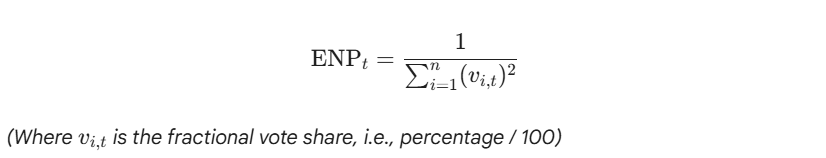

In [7]:
# Calculate fractional vote share and its square
df_features['vote_share_frac'] = df_features['vote_share_pct'] / 100
df_features['vote_share_frac_sq'] = df_features['vote_share_frac'] ** 2

# Group by constituency and year to sum the squared fractions
enp_df = df_features.groupby(['state_canonical', 'constitution', 'election_year_clean'])['vote_share_frac_sq'].sum().reset_index()

# Calculate ENP
enp_df['fragmentation_index'] = 1 / enp_df['vote_share_frac_sq']

# Merge the pre-computed index back to the main dataset
df_features = df_features.merge(enp_df[['state_canonical', 'constitution', 'election_year_clean', 'fragmentation_index']], 
                                on=['state_canonical', 'constitution', 'election_year_clean'], 
                                how='left')

df_features.head()

,id,state,constitution,election_year,candidate,gender,party,age,category,votes_received,...,state_raw,state_canonical,vote_share_lag1,vote_swing,vote_share_lag2,is_winner,is_incumbent,vote_share_frac,vote_share_frac_sq,fragmentation_index
0,8256.0,ANDAMAN AND NICOBAR ISLANDS,ANDAMAN & NICOBAR ISLANDS,1991 (10th LOK SABHA),BISHNU PADA RAY,M,BJP,NaN,NaN,5208.0,...,ANDAMAN AND NICOBAR ISLANDS,ANDAMAN AND NICOBAR ISLANDS,NaN,NaN,NaN,0,0,0.0485,0.002352,2.216692
1,12395.0,ANDAMAN AND NICOBAR ISLANDS,ANDAMAN & NICOBAR ISLANDS,1996 (11th LOK SABHA),BISHNU PADA RAY,M,BJP,NaN,NaN,31097.0,...,ANDAMAN AND NICOBAR ISLANDS,ANDAMAN AND NICOBAR ISLANDS,4.85,19.40,NaN,0,0,0.2425,0.058806,2.389941
2,4665.0,ANDAMAN AND NICOBAR ISLANDS,ANDAMAN & NICOBAR ISLANDS,1998 (12th LOK SABHA),BISHNU PADA RAY,M,BJP,NaN,NaN,51821.0,...,ANDAMAN AND NICOBAR ISLANDS,ANDAMAN AND NICOBAR ISLANDS,24.25,11.28,4.85,0,0,0.3553,0.126238,3.328441
3,4594.0,ANDAMAN AND NICOBAR ISLANDS,ANDAMAN & NICOBAR ISLANDS,1999 (13th LOK SABHA),BISHNU PADA RAY,M,BJP,NaN,NaN,76891.0,...,ANDAMAN AND NICOBAR ISLANDS,ANDAMAN AND NICOBAR ISLANDS,35.53,17.21,24.25,1,0,0.5274,0.278151,2.147515
4,5307.0,ANDAMAN AND NICOBAR ISLANDS,ANDAMAN & NICOBAR ISLANDS,2004 (14th LOK SABHA),BISHNU PADA RAY,M,BJP,54.0,NaN,55294.0,...,ANDAMAN AND NICOBAR ISLANDS,ANDAMAN AND NICOBAR ISLANDS,52.74,-16.79,35.53,0,1,0.3595,0.129240,2.265026


### 4.3.5 Coalition strength score (sum of allied party vote shares)

The aggregate vote share of all parties belonging to a predefined political alliance (e.g., NDA, UPA/INDIA) in a specific constituency during a specific year.

Formula:$$C_{A,t} = \sum_{i \in A} V_{i,t}$$(Where $A$ is the set of parties in the coalition)

In [8]:
# Note: You will need a dictionary mapping parties to alliances for specific years.
# Below is a representative mapping for the logic.
alliance_mapping = {
    'BJP': 'NDA', 'INC': 'UPA', 'TDP': 'NDA', 'DMK': 'UPA' 
    # Add other mappings based on historical alliance data
}

# Map parties to their alliances; default to 'Unaffiliated' if not in dict
df_features['alliance'] = df_features['party'].map(alliance_mapping).fillna('Unaffiliated')

# Sum the vote shares per alliance in each constituency per election year
coalition_df = df_features.groupby(['state_canonical', 'constitution', 'election_year_clean', 'alliance'])['vote_share_pct'].sum().reset_index()
coalition_df.rename(columns={'vote_share_pct': 'coalition_strength_score'}, inplace=True)

# Merge the coalition score back to the candidate/party rows
df_features = df_features.merge(coalition_df, 
                                on=['state_canonical', 'constitution', 'election_year_clean', 'alliance'], 
                                how='left')

In [9]:
df_features.head()

,id,state,constitution,election_year,candidate,gender,party,age,category,votes_received,...,vote_share_lag1,vote_swing,vote_share_lag2,is_winner,is_incumbent,vote_share_frac,vote_share_frac_sq,fragmentation_index,alliance,coalition_strength_score
0,8256.0,ANDAMAN AND NICOBAR ISLANDS,ANDAMAN & NICOBAR ISLANDS,1991 (10th LOK SABHA),BISHNU PADA RAY,M,BJP,NaN,NaN,5208.0,...,NaN,NaN,NaN,0,0,0.0485,0.002352,2.216692,NDA,4.85
1,12395.0,ANDAMAN AND NICOBAR ISLANDS,ANDAMAN & NICOBAR ISLANDS,1996 (11th LOK SABHA),BISHNU PADA RAY,M,BJP,NaN,NaN,31097.0,...,4.85,19.40,NaN,0,0,0.2425,0.058806,2.389941,NDA,24.25
2,4665.0,ANDAMAN AND NICOBAR ISLANDS,ANDAMAN & NICOBAR ISLANDS,1998 (12th LOK SABHA),BISHNU PADA RAY,M,BJP,NaN,NaN,51821.0,...,24.25,11.28,4.85,0,0,0.3553,0.126238,3.328441,NDA,35.53
3,4594.0,ANDAMAN AND NICOBAR ISLANDS,ANDAMAN & NICOBAR ISLANDS,1999 (13th LOK SABHA),BISHNU PADA RAY,M,BJP,NaN,NaN,76891.0,...,35.53,17.21,24.25,1,0,0.5274,0.278151,2.147515,NDA,52.74
4,5307.0,ANDAMAN AND NICOBAR ISLANDS,ANDAMAN & NICOBAR ISLANDS,2004 (14th LOK SABHA),BISHNU PADA RAY,M,BJP,54.0,NaN,55294.0,...,52.74,-16.79,35.53,0,1,0.3595,0.129240,2.265026,NDA,35.95


In [10]:
df_features.to_csv("../data/interim/features_dataset.csv")

In [11]:
df_features.head(20)

,id,state,constitution,election_year,candidate,gender,party,age,category,votes_received,...,vote_share_lag1,vote_swing,vote_share_lag2,is_winner,is_incumbent,vote_share_frac,vote_share_frac_sq,fragmentation_index,alliance,coalition_strength_score
0,8256.0,ANDAMAN AND NICOBAR ISLANDS,ANDAMAN & NICOBAR ISLANDS,1991 (10th LOK SABHA),BISHNU PADA RAY,M,BJP,NaN,NaN,5208.0,...,NaN,NaN,NaN,0,0,0.0485,0.002352,2.216692,NDA,4.85
1,12395.0,ANDAMAN AND NICOBAR ISLANDS,ANDAMAN & NICOBAR ISLANDS,1996 (11th LOK SABHA),BISHNU PADA RAY,M,BJP,NaN,NaN,31097.0,...,4.85,19.40,NaN,0,0,0.2425,0.058806,2.389941,NDA,24.25
2,4665.0,ANDAMAN AND NICOBAR ISLANDS,ANDAMAN & NICOBAR ISLANDS,1998 (12th LOK SABHA),BISHNU PADA RAY,M,BJP,NaN,NaN,51821.0,...,24.25,11.28,4.85,0,0,0.3553,0.126238,3.328441,NDA,35.53
3,4594.0,ANDAMAN AND NICOBAR ISLANDS,ANDAMAN & NICOBAR ISLANDS,1999 (13th LOK SABHA),BISHNU PADA RAY,M,BJP,NaN,NaN,76891.0,...,35.53,17.21,24.25,1,0,0.5274,0.278151,2.147515,NDA,52.74
4,5307.0,ANDAMAN AND NICOBAR ISLANDS,ANDAMAN & NICOBAR ISLANDS,2004 (14th LOK SABHA),BISHNU PADA RAY,M,BJP,54.0,NaN,55294.0,...,52.74,-16.79,35.53,0,1,0.3595,0.129240,2.265026,NDA,35.95
5,5312.0,ANDAMAN AND NICOBAR ISLANDS,ANDAMAN & NICOBAR ISLANDS,2004 (14th LOK SABHA),A K BISWAS,M,BSP,60.0,NaN,1122.0,...,NaN,NaN,NaN,0,0,0.0073,0.000053,2.265026,Unaffiliated,8.27
6,5310.0,ANDAMAN AND NICOBAR ISLANDS,ANDAMAN & NICOBAR ISLANDS,2004 (14th LOK SABHA),N K P NAIR,M,CPI(ML)(L),49.0,NaN,1448.0,...,NaN,NaN,NaN,0,0,0.0094,0.000088,2.265026,Unaffiliated,8.27
7,4080.0,ANDAMAN AND NICOBAR ISLANDS,ANDAMAN & NICOBAR ISLANDS,1980 (7th LOK SABHA),P.K.S. PRASAD,M,CPM,NaN,NaN,16014.0,...,NaN,NaN,NaN,0,0,0.2030,0.041209,2.727701,Unaffiliated,100.01
8,5185.0,ANDAMAN AND NICOBAR ISLANDS,ANDAMAN & NICOBAR ISLANDS,1984 (8th LOK SABHA),NILIMA DAS,F,CPM,NaN,NaN,11086.0,...,20.30,-7.84,NaN,0,0,0.1246,0.015525,2.541091,Unaffiliated,47.16
9,5902.0,ANDAMAN AND NICOBAR ISLANDS,ANDAMAN & NICOBAR ISLANDS,1989 (9th LOK SABHA),TAPAN BEPARI,M,CPM,NaN,NaN,34469.0,...,12.46,18.03,20.30,0,0,0.3049,0.092964,2.888192,Unaffiliated,52.79
